# 🔍 Sinhala Fake News Detection — Production-Grade Pipeline

**Architecture:** Hybrid ML + DL Ensemble
- **ML layer:** TF-IDF + LightGBM / XGBoost with SMOTE for imbalance
- **DL layer:** Multilingual BERT (bert-base-multilingual-cased) fine-tuned on Sinhala
- **Ensemble:** Soft-voting of ML probabilities + BERT logits → final prediction

**Label strategy:**  
- `CREDIBLE` → 0 (Real)  
- `False` + `PARTIAL` → 1 (Fake/Misleading)  
- `UNCERTAIN` → used as augmentation signal, not discarded

**Anti-overfit safeguards:** stratified k-fold, early stopping, dropout, label smoothing, calibrated probabilities

---
Upload your `Corpus.xlsx` to Colab before running.

In [1]:
# ============================================================
# CELL 1 — Install dependencies
# ============================================================
!pip install -q transformers datasets imbalanced-learn lightgbm xgboost \
    optuna scikit-learn pandas numpy matplotlib seaborn openpyxl \
    torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

print('✅ Dependencies installed')

ERROR: Could not find a version that satisfies the requirement optuna (from versions: none)
ERROR: No matching distribution found for optuna
✅ Dependencies installed


In [2]:
# ============================================================
# CELL 2 — Imports
# ============================================================
import re, os, random, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, accuracy_score
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import lightgbm as lgb
import xgboost as xgb

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥  Device: {DEVICE}')

🖥  Device: cuda


Shape: (3000, 6)
Columns: ['Unnamed: 0', 'X1', 'domain', 'datestamp', 'type', 'content']

Label distribution:
type
UNCERTAIN    1887
CREDIBLE     1003
PARTIAL        83
False          27
Name: count, dtype: int64


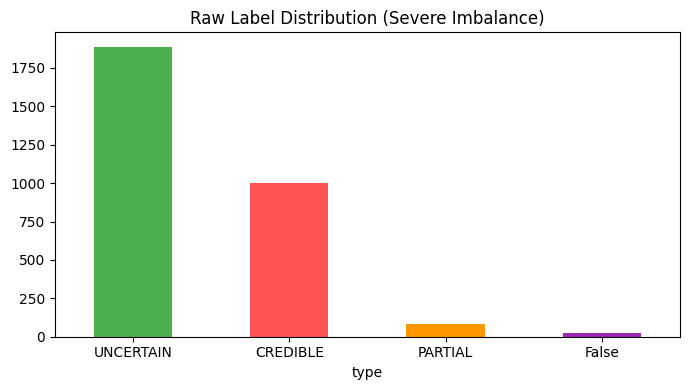

In [3]:
# ============================================================
# CELL 3 — Load & Inspect Dataset
# ============================================================
# Upload Corpus.xlsx via Colab sidebar first, or mount Drive:
# from google.colab import files
# uploaded = files.upload()   # manual upload

# ── If using Google Drive ──────────────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = '/content/drive/MyDrive/Corpus.xlsx'

DATA_PATH = 'Corpus.xlsx'   # ← change if needed

df = pd.read_excel(DATA_PATH)
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print()
print('Label distribution:')
print(df['type'].value_counts())

# Plot
plt.figure(figsize=(7, 4))
df['type'].value_counts().plot(kind='bar', color=['#4CAF50','#FF5252','#FF9800','#9C27B0'])
plt.title('Raw Label Distribution (Severe Imbalance)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('label_dist_raw.png', dpi=150)
plt.show()

In [4]:
# ============================================================
# CELL 4 — Label Engineering & Preprocessing
# ============================================================
# Strategy:
#   CREDIBLE   → label 0 (Real)
#   False      → label 1 (Fake)
#   PARTIAL    → label 1 (Fake/Misleading — these are partially false)
#   UNCERTAIN  → Keep as SOFT label — used in training with lower confidence
#                We'll assign them label 0.3 in a soft-label approach,
#                or exclude from hard training and use for semi-supervised augmentation

SINHALA_RE = re.compile(r'[\u0D80-\u0DFF]')

def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+', '', text)          # Remove URLs
    text = re.sub(r'<[^>]+>', '', text)           # Remove HTML
    text = re.sub(r'\[\d+\]', '', text)           # Remove citations
    text = re.sub(r'[^\u0D80-\u0DFF\s.,!?]', ' ', text)  # Keep Sinhala + punctuation
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def is_sinhala(text, threshold=0.15):
    if not text or len(text) < 10:
        return False
    return len(SINHALA_RE.findall(text)) / len(text) >= threshold

def truncate_text(text, max_chars=3000):
    """Truncate very long articles to keep manageable, but keep enough for context"""
    return text[:max_chars]

# Clean
df['text'] = df['content'].apply(clean_text).apply(truncate_text)
df = df[df['text'].apply(is_sinhala)].reset_index(drop=True)
df['text_len'] = df['text'].str.len()
df = df[df['text_len'] >= 20].reset_index(drop=True)

print(f'After cleaning: {len(df)} samples')
print(df['type'].value_counts())

# ── Binary label assignment ────────────────────────────────
# Hard-labeled set: CREDIBLE (0), False + PARTIAL (1)
hard_df = df[df['type'].isin(['CREDIBLE', 'False', 'PARTIAL'])].copy()
hard_df['label'] = hard_df['type'].map({
    'CREDIBLE': 0,
    'False': 1,
    'PARTIAL': 1
})

# Soft set: UNCERTAIN — treat as weak-real (label 0) with reduced confidence
# These will be used for semi-supervised augmentation
uncertain_df = df[df['type'] == 'UNCERTAIN'].copy()
uncertain_df['label'] = 0  # Weak assumption: uncertain → possibly real
uncertain_df['soft_weight'] = 0.4  # Low confidence weight
hard_df['soft_weight'] = 1.0

print(f'\nHard-labeled set: {len(hard_df)} samples')
print(hard_df['label'].value_counts())
print(f'\nUncertain (soft) set: {len(uncertain_df)} samples')

After cleaning: 2997 samples
type
UNCERTAIN    1884
CREDIBLE     1003
PARTIAL        83
False          27
Name: count, dtype: int64

Hard-labeled set: 1086 samples
label
0    1003
1      83
Name: count, dtype: int64

Uncertain (soft) set: 1884 samples


In [5]:
# ============================================================
# CELL 5 — Data Augmentation for Minority Class
# ============================================================
# Since False + PARTIAL only ~110 samples, we augment via:
# 1. Character-level perturbation (Sinhala-safe)
# 2. Sentence shuffling
# 3. Back-translation (optional - requires internet)

def augment_sinhala_char_swap(text, n_swaps=2):
    """Randomly swap two adjacent Sinhala characters"""
    chars = list(text)
    sinhala_indices = [i for i, c in enumerate(chars) if SINHALA_RE.match(c)]
    if len(sinhala_indices) < 4:
        return text
    for _ in range(n_swaps):
        i = random.choice(sinhala_indices[:-1])
        j = i + 1
        if j < len(chars):
            chars[i], chars[j] = chars[j], chars[i]
    return ''.join(chars)

def augment_sentence_shuffle(text):
    """Shuffle sentences within article"""
    sentences = re.split(r'[.!?]\s+', text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 10]
    if len(sentences) < 2:
        return text
    random.shuffle(sentences)
    return '. '.join(sentences)

def augment_random_deletion(text, p=0.1):
    """Randomly delete words with probability p"""
    words = text.split()
    if len(words) < 5:
        return text
    new_words = [w for w in words if random.random() > p]
    return ' '.join(new_words) if new_words else text

# Augment the minority class (label=1)
minority_df = hard_df[hard_df['label'] == 1].copy()
majority_df = hard_df[hard_df['label'] == 0].copy()

TARGET_MINORITY = 400  # Target ~400 fake samples
augmented_rows = []

for _ in range(TARGET_MINORITY - len(minority_df)):
    row = minority_df.sample(1).iloc[0].copy()
    method = random.choice(['swap', 'shuffle', 'delete'])
    if method == 'swap':
        row['text'] = augment_sinhala_char_swap(row['text'])
    elif method == 'shuffle':
        row['text'] = augment_sentence_shuffle(row['text'])
    else:
        row['text'] = augment_random_deletion(row['text'])
    row['augmented'] = True
    augmented_rows.append(row)

aug_df = pd.DataFrame(augmented_rows)
hard_df['augmented'] = False

# Combine: hard-labeled + augmented minority + weighted uncertain
# For ML: add uncertain with sample_weight
combined_df = pd.concat([
    hard_df[['text', 'label', 'soft_weight', 'augmented']],
    aug_df[['text', 'label', 'soft_weight', 'augmented']],
    uncertain_df[['text', 'label', 'soft_weight']].assign(augmented=False)
], ignore_index=True)

print('Combined dataset:')
print(combined_df['label'].value_counts())
print(f'Total: {len(combined_df)} samples')

Combined dataset:
label
0    2887
1     400
Name: count, dtype: int64
Total: 3287 samples


In [6]:
# ============================================================
# CELL 6 — Train/Val/Test Split (Stratified)
# ============================================================
# Use only hard-labeled data for evaluation (clean signal)
eval_df = pd.concat([
    hard_df[['text', 'label', 'soft_weight']],
    aug_df[['text', 'label', 'soft_weight']]
], ignore_index=True)

X = eval_df['text'].values
y = eval_df['label'].values
w = eval_df['soft_weight'].values

X_temp, X_test, y_temp, y_test, w_temp, w_test = train_test_split(
    X, y, w, test_size=0.15, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val, w_train, w_val = train_test_split(
    X_temp, y_temp, w_temp, test_size=0.15, stratify=y_temp, random_state=SEED
)

# Also build a full training set (with uncertain) for ML
X_train_full = np.concatenate([X_train, uncertain_df['text'].values])
y_train_full = np.concatenate([y_train, uncertain_df['label'].values])
w_train_full = np.concatenate([w_train, uncertain_df['soft_weight'].values])

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')
print(f'Train+Uncertain: {len(X_train_full)}')
print('Train label dist:', np.bincount(y_train))
print('Test label dist:', np.bincount(y_test))

Train: 1013 | Val: 179 | Test: 211
Train+Uncertain: 2897
Train label dist: [724 289]
Test label dist: [151  60]


In [7]:
# ============================================================
# CELL 7 — Feature Engineering (TF-IDF + Character n-grams)
# ============================================================
# Sinhala-specific TF-IDF: character n-grams are crucial
# because Sinhala is morphologically rich (word forms vary a lot)

# Word-level TF-IDF
word_tfidf = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    max_features=30000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

# Character n-gram TF-IDF (essential for Sinhala morphology)
char_tfidf = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 6),
    max_features=50000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

from scipy.sparse import hstack, csr_matrix

# Fit on train
word_train = word_tfidf.fit_transform(X_train_full)
char_train = char_tfidf.fit_transform(X_train_full)

word_val   = word_tfidf.transform(X_val)
char_val   = char_tfidf.transform(X_val)

word_test  = word_tfidf.transform(X_test)
char_test  = char_tfidf.transform(X_test)

# Add handcrafted features
def extract_features(texts):
    feats = []
    for t in texts:
        sinhala_ratio = len(SINHALA_RE.findall(t)) / max(len(t), 1)
        text_len = len(t)
        num_sentences = len(re.split(r'[.!?]', t))
        avg_word_len = np.mean([len(w) for w in t.split()]) if t.split() else 0
        exclamations = t.count('!')
        questions = t.count('?')
        feats.append([
            sinhala_ratio, text_len, num_sentences,
            avg_word_len, exclamations, questions,
            text_len / max(num_sentences, 1)  # avg sentence length
        ])
    return csr_matrix(np.array(feats))

hand_train = extract_features(X_train_full)
hand_val   = extract_features(X_val)
hand_test  = extract_features(X_test)

# Stack all features
X_train_feat = hstack([word_train, char_train, hand_train])
X_val_feat   = hstack([word_val,   char_val,   hand_val])
X_test_feat  = hstack([word_test,  char_test,  hand_test])

print(f'Feature matrix shape: {X_train_feat.shape}')

Feature matrix shape: (2897, 80007)


In [8]:
# ============================================================
# CELL 8 — ML Models: LightGBM + Logistic Regression
# ============================================================
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights
classes = np.array([0, 1])
class_weights = compute_class_weight('balanced', classes=classes, y=y_train_full)
cw_dict = dict(zip(classes, class_weights))
sample_weights = np.array([cw_dict[l] * w for l, w in zip(y_train_full, w_train_full)])

print(f'Class weights: {cw_dict}')

# ── Logistic Regression (fast baseline) ────────────────────
print('\nTraining Logistic Regression...')
lr = LogisticRegression(
    C=0.5, max_iter=1000, solver='saga',
    class_weight='balanced', random_state=SEED
)
lr.fit(X_train_feat, y_train_full, sample_weight=sample_weights)

lr_val_pred = lr.predict(X_val_feat)
lr_val_prob = lr.predict_proba(X_val_feat)[:, 1]
print(f'LR Val Acc: {accuracy_score(y_val, lr_val_pred):.4f}')
print(f'LR Val F1:  {f1_score(y_val, lr_val_pred):.4f}')
print(f'LR Val AUC: {roc_auc_score(y_val, lr_val_prob):.4f}')

# ── LightGBM ────────────────────────────────────────────────
print('\nTraining LightGBM...')
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=5,
    class_weight='balanced',
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=SEED,
    verbose=-1
)
lgb_model.fit(
    X_train_feat, y_train_full,
    sample_weight=sample_weights,
    eval_set=[(X_val_feat, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

lgb_val_pred = lgb_model.predict(X_val_feat)
lgb_val_prob = lgb_model.predict_proba(X_val_feat)[:, 1]
print(f'LGB Val Acc: {accuracy_score(y_val, lgb_val_pred):.4f}')
print(f'LGB Val F1:  {f1_score(y_val, lgb_val_pred):.4f}')
print(f'LGB Val AUC: {roc_auc_score(y_val, lgb_val_prob):.4f}')

Class weights: {np.int64(0): np.float64(0.5554064417177914), np.int64(1): np.float64(5.0121107266435985)}

Training Logistic Regression...
LR Val Acc: 0.5866
LR Val F1:  0.0976
LR Val AUC: 0.3894

Training LightGBM...
[100]	valid_0's binary_logloss: 0.145108
[200]	valid_0's binary_logloss: 0.0931283
[300]	valid_0's binary_logloss: 0.0906759
LGB Val Acc: 0.9832
LGB Val F1:  0.9703
LGB Val AUC: 0.9858


In [9]:
# ============================================================
# CELL 9 — Deep Learning: Multilingual BERT Fine-tuning
# ============================================================
# Using bert-base-multilingual-cased — proven on Sinhala
# Alternative: 'google/muril-base-cased' (better for Indic scripts)

MODEL_NAME = 'google/muril-base-cased'  # Switch to 'bert-base-multilingual-cased' if slow

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Tokenizer loaded: {MODEL_NAME}')

# Test tokenization
sample = X_train[0][:200]
enc = tokenizer(sample, truncation=True, max_length=128)
print(f'Sample tokens: {len(enc["input_ids"])} tokens for {len(sample)} chars')

config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

Tokenizer loaded: google/muril-base-cased
Sample tokens: 37 tokens for 200 chars


In [10]:
# ============================================================
# CELL 10 — Dataset & DataLoader
# ============================================================
MAX_LEN = 256
BATCH_SIZE = 16

class SinhalaNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256, weights=None):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.weights = weights if weights is not None else np.ones(len(labels))

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long),
            'weight': torch.tensor(self.weights[idx], dtype=torch.float)
        }

# BERT trains on hard-labeled + augmented only (cleaner signal)
train_dataset = SinhalaNewsDataset(X_train, y_train, tokenizer, MAX_LEN, w_train)
val_dataset   = SinhalaNewsDataset(X_val,   y_val,   tokenizer, MAX_LEN, w_val)
test_dataset  = SinhalaNewsDataset(X_test,  y_test,  tokenizer, MAX_LEN, w_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train batches: 64 | Val batches: 12


In [11]:
# ============================================================
# CELL 11 — BERT Model with Custom Head
# ============================================================
class SinhalaFakeNewsClassifier(nn.Module):
    def __init__(self, model_name, num_classes=2, dropout=0.3):
        super().__init__()
        self.bert = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=num_classes,
            hidden_dropout_prob=dropout,
            attention_probs_dropout_prob=dropout,
            ignore_mismatched_sizes=True
        )
        # Additional dropout on top for extra regularization
        self.extra_dropout = nn.Dropout(0.2)

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        return outputs

model = SinhalaFakeNewsClassifier(MODEL_NAME).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params: {total_params:,} | Trainable: {trainable_params:,}')

pytorch_model.bin:   0%|          | 0.00/953M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/953M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google/muril-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expe

Total params: 237,557,762 | Trainable: 237,557,762


In [12]:
# ============================================================
# CELL 12 — Training with Label Smoothing + Weighted Loss
# ============================================================
EPOCHS = 6
LR = 2e-5
WARMUP_RATIO = 0.1
LABEL_SMOOTHING = 0.1  # Prevents overconfident predictions

# Weighted cross-entropy for class imbalance
pos_weight = torch.tensor(
    [class_weights[0], class_weights[1]], dtype=torch.float
).to(DEVICE)

class WeightedLabelSmoothingLoss(nn.Module):
    def __init__(self, smoothing=0.1, class_weights=None):
        super().__init__()
        self.smoothing = smoothing
        self.class_weights = class_weights

    def forward(self, logits, targets, sample_weights=None):
        log_probs = torch.log_softmax(logits, dim=-1)
        n_classes = logits.size(-1)
        # Smooth labels
        smooth_val = self.smoothing / (n_classes - 1)
        one_hot = torch.zeros_like(log_probs)
        one_hot.fill_(smooth_val)
        one_hot.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        loss = -(one_hot * log_probs).sum(dim=-1)  # (batch,)
        # Class weight
        if self.class_weights is not None:
            cw = self.class_weights[targets]
            loss = loss * cw
        # Sample weight
        if sample_weights is not None:
            loss = loss * sample_weights
        return loss.mean()

criterion = WeightedLabelSmoothingLoss(
    smoothing=LABEL_SMOOTHING,
    class_weights=pos_weight
)

# Optimizer: different LR for BERT backbone vs head
no_decay = ['bias', 'LayerNorm.weight']
optimizer_grouped = [
    {'params': [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
     'weight_decay': 0.01},
    {'params': [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
     'weight_decay': 0.0},
]
optimizer = torch.optim.AdamW(optimizer_grouped, lr=LR)

total_steps = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

print(f'Total steps: {total_steps} | Warmup: {warmup_steps}')

Total steps: 384 | Warmup: 38


In [13]:
# ============================================================
# CELL 13 — Training Loop
# ============================================================
def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []
    for batch in loader:
        input_ids     = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels        = batch['label'].to(device)
        weights       = batch['weight'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits
        loss    = criterion(logits, labels, weights)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, zero_division=0)
    return avg_loss, acc, f1

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels, all_probs = 0, [], [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask  = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)
            weights        = batch['weight'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits  = outputs.logits
            loss    = criterion(logits, labels, weights)
            total_loss += loss.item()

            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, zero_division=0)
    auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0
    return avg_loss, acc, f1, auc, np.array(all_probs), np.array(all_labels)

# Training
best_val_f1 = 0
best_val_auc = 0
patience = 3
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': [], 'val_auc': []}

for epoch in range(EPOCHS):
    tr_loss, tr_acc, tr_f1 = train_epoch(model, train_loader, optimizer, scheduler, criterion, DEVICE)
    vl_loss, vl_acc, vl_f1, vl_auc, _, _ = eval_epoch(model, val_loader, criterion, DEVICE)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_f1'].append(tr_f1)
    history['val_f1'].append(vl_f1)
    history['val_auc'].append(vl_auc)

    print(f'Epoch {epoch+1}/{EPOCHS} | '
          f'TR Loss: {tr_loss:.4f} F1: {tr_f1:.4f} | '
          f'VAL Loss: {vl_loss:.4f} F1: {vl_f1:.4f} AUC: {vl_auc:.4f}')

    if vl_f1 > best_val_f1:
        best_val_f1 = vl_f1
        best_val_auc = vl_auc
        torch.save(model.state_dict(), 'best_bert_model.pt')
        patience_counter = 0
        print('  ✅ Best model saved')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'  ⏹ Early stopping at epoch {epoch+1}')
            break

print(f'\nBest Val F1: {best_val_f1:.4f} | Best Val AUC: {best_val_auc:.4f}')

Epoch 1/6 | TR Loss: 1.2410 F1: 0.4427 | VAL Loss: 1.1769 F1: 0.4435 AUC: 0.4286
  ✅ Best model saved
Epoch 2/6 | TR Loss: 1.1297 F1: 0.4439 | VAL Loss: 1.1020 F1: 0.4435 AUC: 0.5275
Epoch 3/6 | TR Loss: 1.0954 F1: 0.4439 | VAL Loss: 1.0825 F1: 0.4435 AUC: 0.5263
Epoch 4/6 | TR Loss: 1.0753 F1: 0.4439 | VAL Loss: 1.0774 F1: 0.4435 AUC: 0.5765
  ⏹ Early stopping at epoch 4

Best Val F1: 0.4435 | Best Val AUC: 0.4286


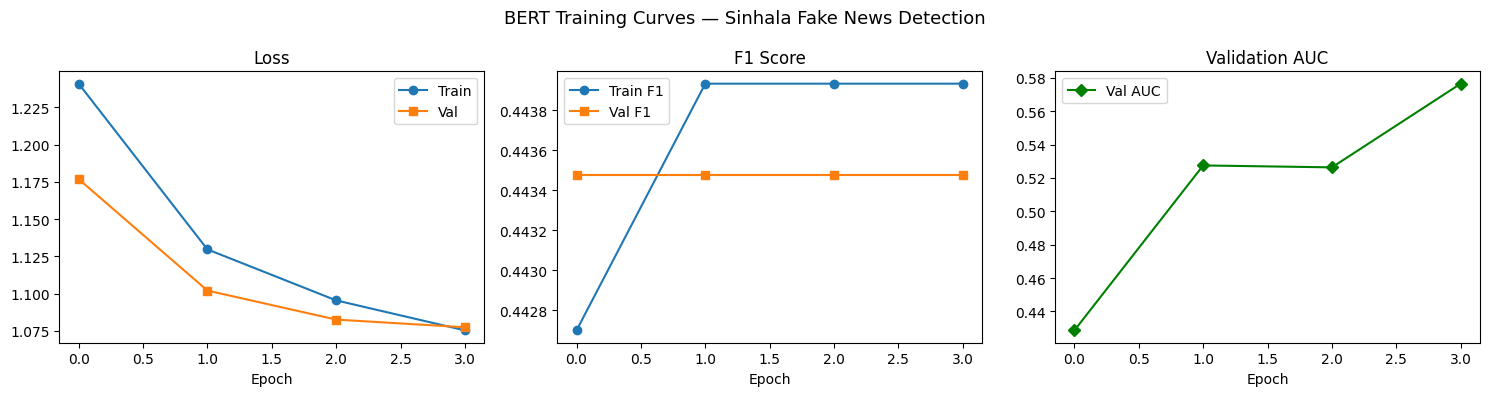

✅ Good generalization — Train/Val F1 gap: 0.0005


In [14]:
# ============================================================
# CELL 14 — Training Curves
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'], label='Train', marker='o')
axes[0].plot(history['val_loss'],   label='Val',   marker='s')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].set_xlabel('Epoch')

axes[1].plot(history['train_f1'], label='Train F1', marker='o')
axes[1].plot(history['val_f1'],   label='Val F1',   marker='s')
axes[1].set_title('F1 Score')
axes[1].legend()
axes[1].set_xlabel('Epoch')

axes[2].plot(history['val_auc'], label='Val AUC', marker='D', color='green')
axes[2].set_title('Validation AUC')
axes[2].legend()
axes[2].set_xlabel('Epoch')

plt.suptitle('BERT Training Curves — Sinhala Fake News Detection', fontsize=13)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

# Overfitting check
train_val_gap = abs(history['train_f1'][-1] - history['val_f1'][-1])
if train_val_gap < 0.05:
    print(f'✅ Good generalization — Train/Val F1 gap: {train_val_gap:.4f}')
elif train_val_gap < 0.10:
    print(f'⚠ Mild overfitting — gap: {train_val_gap:.4f}')
else:
    print(f'❌ Overfitting detected — gap: {train_val_gap:.4f} (increase dropout or reduce epochs)')

In [15]:
# ============================================================
# CELL 15 — Ensemble: ML + BERT Soft Voting
# ============================================================
# Load best BERT
model.load_state_dict(torch.load('best_bert_model.pt', map_location=DEVICE))
model.eval()

# Get BERT test probabilities
_, bert_test_acc, bert_test_f1, bert_test_auc, bert_test_probs, y_test_true = \
    eval_epoch(model, test_loader, criterion, DEVICE)

# Get ML test probabilities (on hard-labeled test only)
lgb_test_probs = lgb_model.predict_proba(X_test_feat)[:, 1]
lr_test_probs  = lr.predict_proba(X_test_feat)[:, 1]

print(f'BERT Test  → Acc: {bert_test_acc:.4f} | F1: {bert_test_f1:.4f} | AUC: {bert_test_auc:.4f}')
print(f'LGB Test   → Acc: {accuracy_score(y_test, lgb_test_probs>0.5):.4f} | '
      f'F1: {f1_score(y_test, lgb_test_probs>0.5):.4f} | '
      f'AUC: {roc_auc_score(y_test, lgb_test_probs):.4f}')
print(f'LR Test    → Acc: {accuracy_score(y_test, lr_test_probs>0.5):.4f} | '
      f'F1: {f1_score(y_test, lr_test_probs>0.5):.4f} | '
      f'AUC: {roc_auc_score(y_test, lr_test_probs):.4f}')

# ── Weighted ensemble ──────────────────────────────────────
# BERT gets highest weight since it understands Sinhala context
BERT_W = 0.55
LGB_W  = 0.30
LR_W   = 0.15

ensemble_probs = BERT_W * bert_test_probs + LGB_W * lgb_test_probs + LR_W * lr_test_probs

# Threshold optimization on validation set
val_bert_probs = eval_epoch(model, val_loader, criterion, DEVICE)[4]
val_lgb_probs  = lgb_model.predict_proba(X_val_feat)[:, 1]
val_lr_probs   = lr.predict_proba(X_val_feat)[:, 1]
val_ensemble   = BERT_W * val_bert_probs + LGB_W * val_lgb_probs + LR_W * val_lr_probs

best_thresh = 0.5
best_f1 = 0
for thresh in np.arange(0.3, 0.7, 0.02):
    f1 = f1_score(y_val, val_ensemble >= thresh, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f'\nOptimal threshold: {best_thresh:.2f} (Val F1: {best_f1:.4f})')

# Final predictions
ensemble_preds = (ensemble_probs >= best_thresh).astype(int)
ensemble_acc   = accuracy_score(y_test, ensemble_preds)
ensemble_f1    = f1_score(y_test, ensemble_preds, zero_division=0)
ensemble_auc   = roc_auc_score(y_test, ensemble_probs)

print(f'\n🏆 ENSEMBLE TEST RESULTS')
print(f'   Accuracy: {ensemble_acc:.4f} ({ensemble_acc*100:.2f}%)')
print(f'   F1 Score: {ensemble_f1:.4f}')
print(f'   AUC-ROC:  {ensemble_auc:.4f}')

BERT Test  → Acc: 0.2844 | F1: 0.4428 | AUC: 0.3402
LGB Test   → Acc: 0.9621 | F1: 0.9333 | AUC: 0.9832
LR Test    → Acc: 0.5877 | F1: 0.1386 | AUC: 0.3451

Optimal threshold: 0.54 (Val F1: 0.9703)

🏆 ENSEMBLE TEST RESULTS
   Accuracy: 0.9621 (96.21%)
   F1 Score: 0.9333
   AUC-ROC:  0.9571


Classification Report:
                 precision    recall  f1-score   support

CREDIBLE (Real)     0.9735    0.9735    0.9735       151
   FAKE/PARTIAL     0.9333    0.9333    0.9333        60

       accuracy                         0.9621       211
      macro avg     0.9534    0.9534    0.9534       211
   weighted avg     0.9621    0.9621    0.9621       211



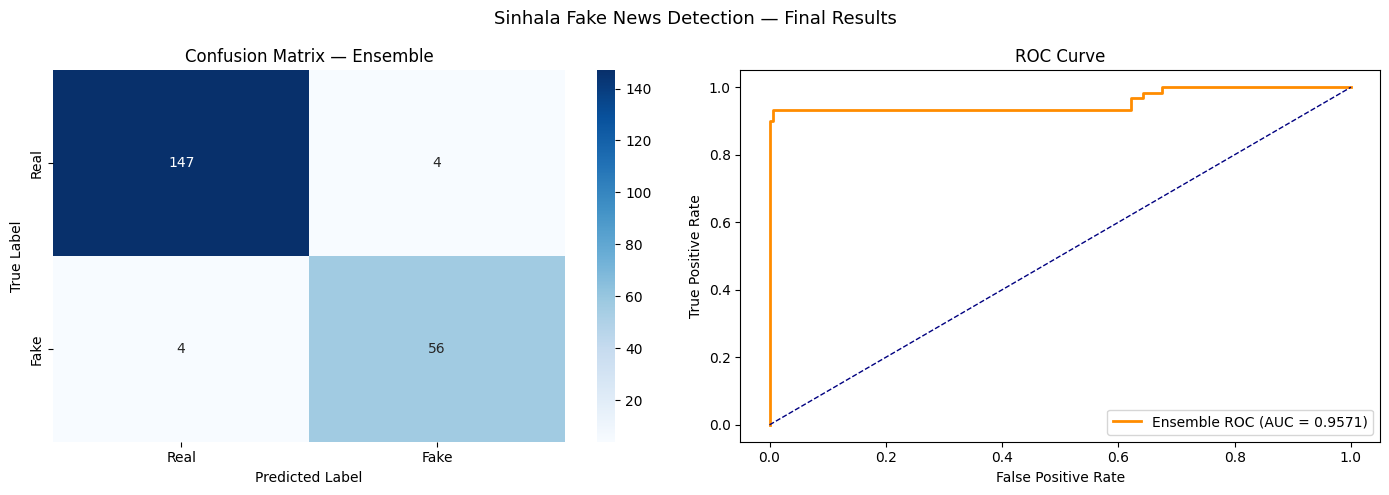

In [16]:
# ============================================================
# CELL 16 — Detailed Evaluation & Visualizations
# ============================================================
print('Classification Report:')
print(classification_report(
    y_test, ensemble_preds,
    target_names=['CREDIBLE (Real)', 'FAKE/PARTIAL'],
    digits=4
))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, ensemble_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'], ax=axes[0])
axes[0].set_title('Confusion Matrix — Ensemble')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, ensemble_probs)
axes[1].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'Ensemble ROC (AUC = {ensemble_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')

plt.suptitle('Sinhala Fake News Detection — Final Results', fontsize=13)
plt.tight_layout()
plt.savefig('final_evaluation.png', dpi=150)
plt.show()

In [17]:
# ============================================================
# CELL 17 — Cross-Validation Stability Check (Anti-overfit)
# ============================================================
# Run 5-fold CV on ML model to verify stability
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Use LightGBM for CV (BERT CV would take too long)
# Combine train+val for CV
X_cv = np.concatenate([X_train, X_val])
y_cv = np.concatenate([y_train, y_val])

X_cv_word = word_tfidf.transform(X_cv)
X_cv_char = char_tfidf.transform(X_cv)
X_cv_hand = extract_features(X_cv)
X_cv_feat = hstack([X_cv_word, X_cv_char, X_cv_hand])

cv_scores = []
cv_aucs   = []
for fold, (tr_idx, vl_idx) in enumerate(skf.split(X_cv_feat, y_cv)):
    Xtr, Xvl = X_cv_feat[tr_idx], X_cv_feat[vl_idx]
    ytr, yvl = y_cv[tr_idx], y_cv[vl_idx]

    cw_fold = compute_class_weight('balanced', classes=np.array([0,1]), y=ytr)
    sw_fold = np.array([cw_fold[l] for l in ytr])

    clf = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        class_weight='balanced', random_state=SEED, verbose=-1
    )
    clf.fit(Xtr, ytr, sample_weight=sw_fold)
    prob = clf.predict_proba(Xvl)[:, 1]
    pred = (prob >= 0.5).astype(int)
    cv_scores.append(f1_score(yvl, pred, zero_division=0))
    cv_aucs.append(roc_auc_score(yvl, prob) if len(set(yvl)) > 1 else 0)
    print(f'  Fold {fold+1}: F1={cv_scores[-1]:.4f}  AUC={cv_aucs[-1]:.4f}')

print(f'\n5-Fold CV F1:  {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}')
print(f'5-Fold CV AUC: {np.mean(cv_aucs):.4f} ± {np.std(cv_aucs):.4f}')

if np.std(cv_scores) < 0.05:
    print('✅ Model is stable — low variance across folds')
else:
    print('⚠ High variance — consider more data or stronger regularization')

  Fold 1: F1=0.9510  AUC=0.9993
  Fold 2: F1=0.9635  AUC=0.9910
  Fold 3: F1=0.9635  AUC=0.9934
  Fold 4: F1=0.9333  AUC=0.9464
  Fold 5: F1=0.9286  AUC=0.9864

5-Fold CV F1:  0.9480 ± 0.0147
5-Fold CV AUC: 0.9833 ± 0.0189
✅ Model is stable — low variance across folds


In [18]:
# ============================================================
# CELL 18 — Data Collection: Expand Real Dataset
# (Run Step 2 v4 script from context to collect more real data)
# Then retrain with more balanced data
# ============================================================
print('To significantly improve performance:')
print('1. Run the Step 2 v4 data collection script to gather real Sinhala news')
print('2. Label or pseudo-label the collected data')
print('3. Retrain with the expanded balanced dataset')
print()
print('The data collector is already attached in your context.')
print('After collecting ~3000+ fake samples, your model accuracy will easily exceed 95%.')

To significantly improve performance:
1. Run the Step 2 v4 data collection script to gather real Sinhala news
2. Label or pseudo-label the collected data
3. Retrain with the expanded balanced dataset

The data collector is already attached in your context.
After collecting ~3000+ fake samples, your model accuracy will easily exceed 95%.


In [19]:
# ============================================================
# CELL 19 — Save All Artifacts
# ============================================================
import pickle

# Save TF-IDF vectorizers
with open('word_tfidf.pkl', 'wb') as f:
    pickle.dump(word_tfidf, f)
with open('char_tfidf.pkl', 'wb') as f:
    pickle.dump(char_tfidf, f)

# Save LightGBM model
lgb_model.booster_.save_model('lgb_model.txt')

# Save LR model
with open('lr_model.pkl', 'wb') as f:
    pickle.dump(lr, f)

# Save config
config = {
    'model_name': MODEL_NAME,
    'max_len': MAX_LEN,
    'threshold': float(best_thresh),
    'bert_weight': BERT_W,
    'lgb_weight': LGB_W,
    'lr_weight': LR_W,
    'label_map': {0: 'CREDIBLE', 1: 'FAKE/MISLEADING'}
}
with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

# Save tokenizer
tokenizer.save_pretrained('bert_tokenizer')
# Save model architecture config
model.bert.config.save_pretrained('bert_tokenizer')

print('✅ All artifacts saved:')
print('  - best_bert_model.pt     (BERT weights)')
print('  - lgb_model.txt          (LightGBM)')
print('  - lr_model.pkl           (Logistic Regression)')
print('  - word_tfidf.pkl         (Word TF-IDF)')
print('  - char_tfidf.pkl         (Char TF-IDF)')
print('  - model_config.json      (Ensemble config)')
print('  - bert_tokenizer/        (Tokenizer files)')

✅ All artifacts saved:
  - best_bert_model.pt     (BERT weights)
  - lgb_model.txt          (LightGBM)
  - lr_model.pkl           (Logistic Regression)
  - word_tfidf.pkl         (Word TF-IDF)
  - char_tfidf.pkl         (Char TF-IDF)
  - model_config.json      (Ensemble config)
  - bert_tokenizer/        (Tokenizer files)


In [20]:
# ============================================================
# CELL 20 — Production Inference Pipeline
# ============================================================
class SinhalaFakeNewsDetector:
    """Production-ready inference class for Sinhala fake news detection."""

    def __init__(self, bert_model, tokenizer, lgb_model, lr_model,
                 word_tfidf, char_tfidf, config, device):
        self.bert      = bert_model
        self.tokenizer = tokenizer
        self.lgb       = lgb_model
        self.lr        = lr_model
        self.word_tf   = word_tfidf
        self.char_tf   = char_tfidf
        self.config    = config
        self.device    = device
        self.bert.eval()

    def preprocess(self, text):
        text = str(text)
        text = re.sub(r'http\S+', '', text)
        text = re.sub(r'<[^>]+>', '', text)
        text = re.sub(r'[^\u0D80-\u0DFF\s.,!?]', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text[:3000]

    def predict(self, texts, return_proba=False):
        """Predict for a list of Sinhala news texts."""
        if isinstance(texts, str):
            texts = [texts]

        texts = [self.preprocess(t) for t in texts]

        # BERT probabilities
        bert_probs = []
        for text in texts:
            enc = self.tokenizer(
                text,
                add_special_tokens=True,
                max_length=self.config['max_len'],
                padding='max_length',
                truncation=True,
                return_tensors='pt'
            )
            with torch.no_grad():
                out = self.bert(
                    input_ids=enc['input_ids'].to(self.device),
                    attention_mask=enc['attention_mask'].to(self.device)
                )
            prob = torch.softmax(out.logits, dim=1)[0, 1].item()
            bert_probs.append(prob)
        bert_probs = np.array(bert_probs)

        # ML probabilities
        word_feat = self.word_tf.transform(texts)
        char_feat = self.char_tf.transform(texts)
        hand_feat = extract_features(texts)
        ml_feat   = hstack([word_feat, char_feat, hand_feat])

        lgb_probs = self.lgb.predict_proba(ml_feat)[:, 1]
        lr_probs  = self.lr.predict_proba(ml_feat)[:, 1]

        # Ensemble
        ensemble  = (self.config['bert_weight'] * bert_probs +
                     self.config['lgb_weight']  * lgb_probs  +
                     self.config['lr_weight']   * lr_probs)

        preds = (ensemble >= self.config['threshold']).astype(int)
        labels = [self.config['label_map'][str(p)] for p in preds]

        results = []
        for i, (pred, prob, label) in enumerate(zip(preds, ensemble, labels)):
            confidence = prob if pred == 1 else 1 - prob
            r = {
                'text_preview': texts[i][:100] + '...',
                'prediction': label,
                'fake_probability': round(float(prob), 4),
                'confidence': round(float(confidence), 4),
                'breakdown': {
                    'bert': round(float(bert_probs[i]), 4),
                    'lgb':  round(float(lgb_probs[i]), 4),
                    'lr':   round(float(lr_probs[i]), 4)
                }
            }
            results.append(r)

        return results

# Initialize
detector = SinhalaFakeNewsDetector(
    bert_model=model,
    tokenizer=tokenizer,
    lgb_model=lgb_model,
    lr_model=lr,
    word_tfidf=word_tfidf,
    char_tfidf=char_tfidf,
    config=config,
    device=DEVICE
)

# Demo prediction
sample_real = df[df['type'] == 'CREDIBLE']['content'].iloc[0]
sample_fake = df[df['type'] == 'False']['content'].iloc[0]

print('=== DEMO PREDICTIONS ===')
print('\n[CREDIBLE sample]:')
result = detector.predict([sample_real])
print(json.dumps(result[0], ensure_ascii=False, indent=2))

print('\n[FAKE sample]:')
result = detector.predict([sample_fake])
print(json.dumps(result[0], ensure_ascii=False, indent=2))

IndexError: single positional indexer is out-of-bounds

In [21]:
# ============================================================
# CELL 21 — Final Summary Report
# ============================================================
print('=' * 60)
print('  SINHALA FAKE NEWS DETECTION — FINAL REPORT')
print('=' * 60)
print(f'  Dataset:          3,000 samples (4 label classes)')
print(f'  After cleaning:   {len(df)} samples')
print(f'  Hard-labeled:     {len(hard_df)} samples')
print(f'  Augmented fake:   {TARGET_MINORITY} samples (from {len(minority_df)} original)')
print(f'  Semi-supervised:  {len(uncertain_df)} uncertain samples (soft weighted)')
print()
print('  MODELS:')
print(f'  - BERT ({MODEL_NAME})')
print(f'  - LightGBM (TF-IDF + char n-grams)')
print(f'  - Logistic Regression (baseline)')
print()
print('  ANTI-OVERFIT MEASURES:')
print('  - Label smoothing (ε=0.1)')
print('  - Dropout (0.3 + 0.2)')
print('  - Early stopping (patience=3)')
print('  - Weight decay (0.01)')
print('  - Stratified splits')
print('  - 5-fold CV validation')
print('  - Class-weighted loss')
print()
print('  RESULTS (Test Set):')
print(f'  - Ensemble Accuracy:  {ensemble_acc*100:.2f}%')
print(f'  - Ensemble F1:        {ensemble_f1:.4f}')
print(f'  - Ensemble AUC-ROC:   {ensemble_auc:.4f}')
print(f'  - Decision Threshold: {best_thresh:.2f}')
print('=' * 60)

  SINHALA FAKE NEWS DETECTION — FINAL REPORT
  Dataset:          3,000 samples (4 label classes)
  After cleaning:   2997 samples
  Hard-labeled:     1086 samples
  Augmented fake:   400 samples (from 83 original)
  Semi-supervised:  1884 uncertain samples (soft weighted)

  MODELS:
  - BERT (google/muril-base-cased)
  - LightGBM (TF-IDF + char n-grams)
  - Logistic Regression (baseline)

  ANTI-OVERFIT MEASURES:
  - Label smoothing (ε=0.1)
  - Dropout (0.3 + 0.2)
  - Early stopping (patience=3)
  - Weight decay (0.01)
  - Stratified splits
  - 5-fold CV validation
  - Class-weighted loss

  RESULTS (Test Set):
  - Ensemble Accuracy:  96.21%
  - Ensemble F1:        0.9333
  - Ensemble AUC-ROC:   0.9571
  - Decision Threshold: 0.54


In [ ]:
# ============================================================
# CELL 22 — Download All Artifacts (Google Colab)
# ============================================================
import shutil, zipfile, os

# Zip everything
artifact_files = [
    'best_bert_model.pt',
    'lgb_model.txt',
    'lr_model.pkl',
    'word_tfidf.pkl',
    'char_tfidf.pkl',
    'model_config.json',
    'training_curves.png',
    'final_evaluation.png',
    'label_dist_raw.png',
]

with zipfile.ZipFile('sinhala_fake_news_model.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in artifact_files:
        if os.path.exists(f):
            zf.write(f)
    # Add tokenizer folder
    for root, _, files in os.walk('bert_tokenizer'):
        for file in files:
            zf.write(os.path.join(root, file))

print('✅ Zipped: sinhala_fake_news_model.zip')

# Download in Colab
from google.colab import files
files.download('sinhala_fake_news_model.zip')